In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import numpy as np
import os 

### Loading and preparing the data

In [2]:
MAIN_DIR = "/home/joan/Desktop/PROJECTS/Glioblastomas/"
RESULTS = f"{MAIN_DIR}/RESULTS-GBM_4-cohorts_UMAP-Risks"
os.makedirs(f"{RESULTS}", exist_ok=True)

daysXmonth = 365/12
voxel_size = (0.5**3) * (1/1000) # 0.5 (mm³/voxel) X 0.001 (cm³/mm³)   

In [3]:
hcpex_complete = pd.read_csv(f"{RESULTS}/data-clinical_parcellation-hcpex_4-cohorts.csv", sep=",")
aal3_complete = pd.read_csv(f"{RESULTS}/data-clinical_parcellation-aal3_4-cohorts.csv", sep=",")

In [4]:
metrics_covariates = [
    'size', 'density', 'avg_degree', 
    'avg_clustering', 'modularity', 'global_efficiency', 'avg_local_efficiency', 'avg_shortest_path_length', 
    'avg_participation_coef', 'avg_eigenvector_centrality', 'avg_betweenness_centrality', 'avg_closeness_centrality', 'avg_edge_betwenness_centrality', 'avg_percolation_centrality', 
    'deg_assortativity', 'powerlaw_exponent', 'LLR_distribution', 's_metric_SF', 'avg_rich_club_coef'
]

clinical_covariates = [
    'age', 'sex', 'eor', 'mgmt', 'kps (preop)'
]

tract_covariates = [
    'Whole TDMap', 'Whole lesion TDMap'
]

morphology_covariates = [
    "Whole tumor size (voxels)"
]

survival_covariates = [
    'cohort', 'site', 
    'OS (days) - corrected', 'status'
]

In [5]:
hcpex_metrics = hcpex_complete[
    survival_covariates+metrics_covariates+tract_covariates+morphology_covariates
].copy().dropna()
print(f"HCPEx -- N={len(hcpex_metrics)} ({len(hcpex_complete)-len(hcpex_metrics)} samples with 'NaN' entries discarded)")

aal3_metrics = aal3_complete[
    survival_covariates+metrics_covariates+tract_covariates+morphology_covariates
].copy().dropna()
print(f"AAL3 -- N={len(aal3_metrics)} ({len(aal3_complete)-len(aal3_metrics)} samples with 'NaN' entries discarded)")

HCPEx -- N=997 (2 samples with 'NaN' entries discarded)
AAL3 -- N=997 (2 samples with 'NaN' entries discarded)


# Univariate survival analysis

In [ ]:
from utils.metrics import process_metric, test_metric

### No validation on external cohorts

In [7]:
results, results_text = [], []
r = process_metric(
        hcpex_metrics,
        "density",
        survival="OS (days) - corrected",
        status="status",
        random_state=42,
        n_perm=1000,
        round_decimal=6
    )
results.append(r[0])
results_text.append(r[1])

r = process_metric(
        hcpex_metrics,
        "modularity",
        survival="OS (days) - corrected",
        status="status",
        random_state=42,
        n_perm=1000,
        round_decimal=6
    )
results.append(r[0])
results_text.append(r[1])

In [8]:
pd.DataFrame(results)

,metric,cindex,cindex_pvalue,cox_hazard_ratio,cox_hr_ci_lower_95%,cox_hr_ci_upper_95%,cox_log_hr,cox_log_hr_pvalue,logrank_5050_chi2,logrank_5050_pvalue,logrank_4060_chi2,logrank_4060_pvalue,logrank_2575_chi2,logrank_2575_pvalue
0,density,0.560258,0.0,54.954796,10.239148,294.94930,4.006511,0.000003,9.091193,0.002568,9.671125,0.001872,13.876975,0.000195
1,modularity,0.571371,0.0,17.899065,3.096614,103.46026,2.884748,0.001270,14.495890,0.000140,17.330415,0.000031,23.674413,0.000001


### Validation on external cohorts TCGA and RHUH

In [ ]:
hcpex_train = hcpex_metrics.loc[hcpex_metrics["cohort"]<=1].copy() # UCSF + UPENN
hcpex_test = hcpex_metrics.loc[hcpex_metrics["cohort"]>1].copy() # TCGA + RHUH
    
results, results_text = [], []
r = test_metric(
        hcpex_train,
        hcpex_test,
        "density",
        survival="OS (days) - corrected",
        status="status",
        random_state=42,
        n_perm=1000,
        round_decimal=6
    )
results.append(r[0])
results_text.append(r[1])

r = test_metric(
        hcpex_train,
        hcpex_test,
        "modularity",
        survival="OS (days) - corrected",
        status="status",
        random_state=42,
        n_perm=1000,
        round_decimal=6
    )
results.append(r[0])
results_text.append(r[1])

In [10]:
pd.DataFrame(results)

,metric,cindex,cindex_pvalue,cox_hazard_ratio,cox_hr_ci_lower_95%,cox_hr_ci_upper_95%,cox_log_hr,cox_log_hr_pvalue,logrank_5050_chi2,logrank_5050_pvalue,logrank_4060_chi2,logrank_4060_pvalue,logrank_2575_chi2,logrank_2575_pvalue
0,density,0.612171,0.000,39.833254,6.719488,236.132291,3.684702,0.000050,9.330173,0.002254,7.726357,0.005442,4.749351,0.029309
1,modularity,0.566216,0.016,15.139768,2.409895,95.113077,2.717325,0.003755,2.357249,0.124702,2.518245,0.112536,6.758081,0.009332


### Validation on randomized validation splits

In [6]:
from utils.metrics import repeated_validation

metrics = ["density", "modularity"]

results = repeated_validation(
    hcpex_metrics,
    metrics,
    N_val=10,
    test_size=0.2,
    n_perm=50
)

In [8]:
results["density"]

,metric,cindex,cindex_pvalue,cox_hazard_ratio,cox_hr_ci_lower_95%,cox_hr_ci_upper_95%,cox_log_hr,cox_log_hr_pvalue,logrank_5050_chi2,logrank_5050_pvalue,logrank_4060_chi2,logrank_4060_pvalue,logrank_2575_chi2,logrank_2575_pvalue
0,density,0.564903,0.00,61.451413,9.406890,401.437249,4.118247,1.702419e-05,1.168242,0.279763,1.409625,0.235119,1.380630,0.239994
1,density,0.583832,0.00,38.231064,5.804836,251.792506,3.643648,1.514754e-04,2.763631,0.096429,2.941050,0.086355,13.613330,0.000225
2,density,0.558012,0.00,63.669556,9.347766,433.666410,4.153707,2.202306e-05,0.332083,0.564435,1.355136,0.244382,2.369398,0.123735
3,density,0.556925,0.02,69.141181,10.336929,462.468373,4.236151,1.248968e-05,2.274946,0.131480,1.066790,0.301672,0.821050,0.364873
4,density,0.557417,0.00,60.226058,9.444848,384.037714,4.098105,1.454161e-05,1.993020,0.158025,1.201161,0.273090,1.813366,0.178105
5,density,0.525684,0.26,110.592537,17.348616,704.996271,4.705853,6.382435e-07,0.000692,0.979009,0.004931,0.944015,0.803196,0.370139
6,density,0.558913,0.00,47.760905,7.198589,316.882097,3.866207,6.217346e-05,4.587920,0.032198,4.927823,0.026428,4.552501,0.032871
7,density,0.584669,0.00,47.364928,7.213940,310.986264,3.857882,5.869824e-05,4.737475,0.029512,6.748389,0.009383,5.192285,0.022687
8,density,0.565980,0.00,31.560611,4.648409,214.282412,3.451910,4.120392e-04,1.532648,0.215715,1.805557,0.179042,5.654181,0.017414
9,density,0.566924,0.00,68.085107,10.355090,447.662164,4.220758,1.119929e-05,5.061902,0.024457,2.002602,0.157029,1.798091,0.179944


(array([2., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
        0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([6.23033781e-04, 9.91972728e-03, 1.92164208e-02, 2.85131143e-02,
        3.78098078e-02, 4.71065013e-02, 5.64031948e-02, 6.56998883e-02,
        7.49965818e-02, 8.42932753e-02, 9.35899688e-02, 1.02886662e-01,
        1.12183356e-01, 1.21480049e-01, 1.30776743e-01, 1.40073436e-01,
        1.49370130e-01, 1.58666823e-01, 1.67963517e-01, 1.77260210e-01,
        1.86556904e-01, 1.95853597e-01, 2.05150291e-01, 2.14446984e-01,
        2.23743678e-01, 2.33040371e-01, 2.42337065e-01, 2.51633758e-01,
        2.60930452e-01, 2.70227145e-01, 2.7952

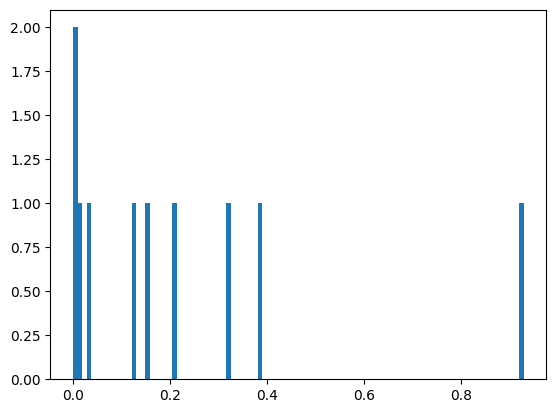

In [16]:
dx = 0.01
plt.hist(results["modularity"]["logrank_4060_pvalue"], bins=int(1/dx))

In [19]:
tet.head()

,metric,cindex,cindex_pvalue,cox_hazard_ratio,cox_hr_ci_lower_95%,cox_hr_ci_upper_95%,cox_log_hr,cox_log_hr_pvalue,logrank_5050_chi2,logrank_5050_pvalue,logrank_4060_chi2,logrank_4060_pvalue,logrank_2575_chi2,logrank_2575_pvalue,split_id
0,density,0.564903,0.0,61.451413,9.406890,401.437249,4.118247,0.000017,1.168242,0.279763,1.409625,0.235119,1.380630,0.239994,0
1,modularity,0.572511,0.0,12.195071,1.817367,81.832554,2.501032,0.010023,0.547187,0.459470,0.989759,0.319801,5.074159,0.024285,0
2,density,0.583832,0.0,38.231064,5.804836,251.792506,3.643648,0.000151,2.763631,0.096429,2.941050,0.086355,13.613330,0.000225,1
3,modularity,0.562801,0.0,17.411090,2.573039,117.816330,2.857107,0.003403,2.817661,0.093232,2.383971,0.122586,2.144771,0.143056,1
4,density,0.558012,0.0,63.669556,9.347766,433.666410,4.153707,0.000022,0.332083,0.564435,1.355136,0.244382,2.369398,0.123735,2


# Low-dimensional representations

### Scaling and normalizing the data

In [7]:
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
)

In [ ]:
standard = StandardScaler(with_mean=True, with_std=True)
minmax = MinMaxScaler(feature_range=(0,1), clip=False)
robust = RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0), unit_variance=False)
powerT = PowerTransformer(method='yeo-johnson', standardize=True)

hcpex_standard = standard.fit_transform(hcpex_metrics[metrics_covariates])
hcpex_minmax = minmax.fit_transform(hcpex_metrics[metrics_covariates])
hcpex_robust = robust.fit_transform(hcpex_metrics[metrics_covariates])
hcpex_powerT = powerT.fit_transform(hcpex_metrics[metrics_covariates])

### Principal component analysis

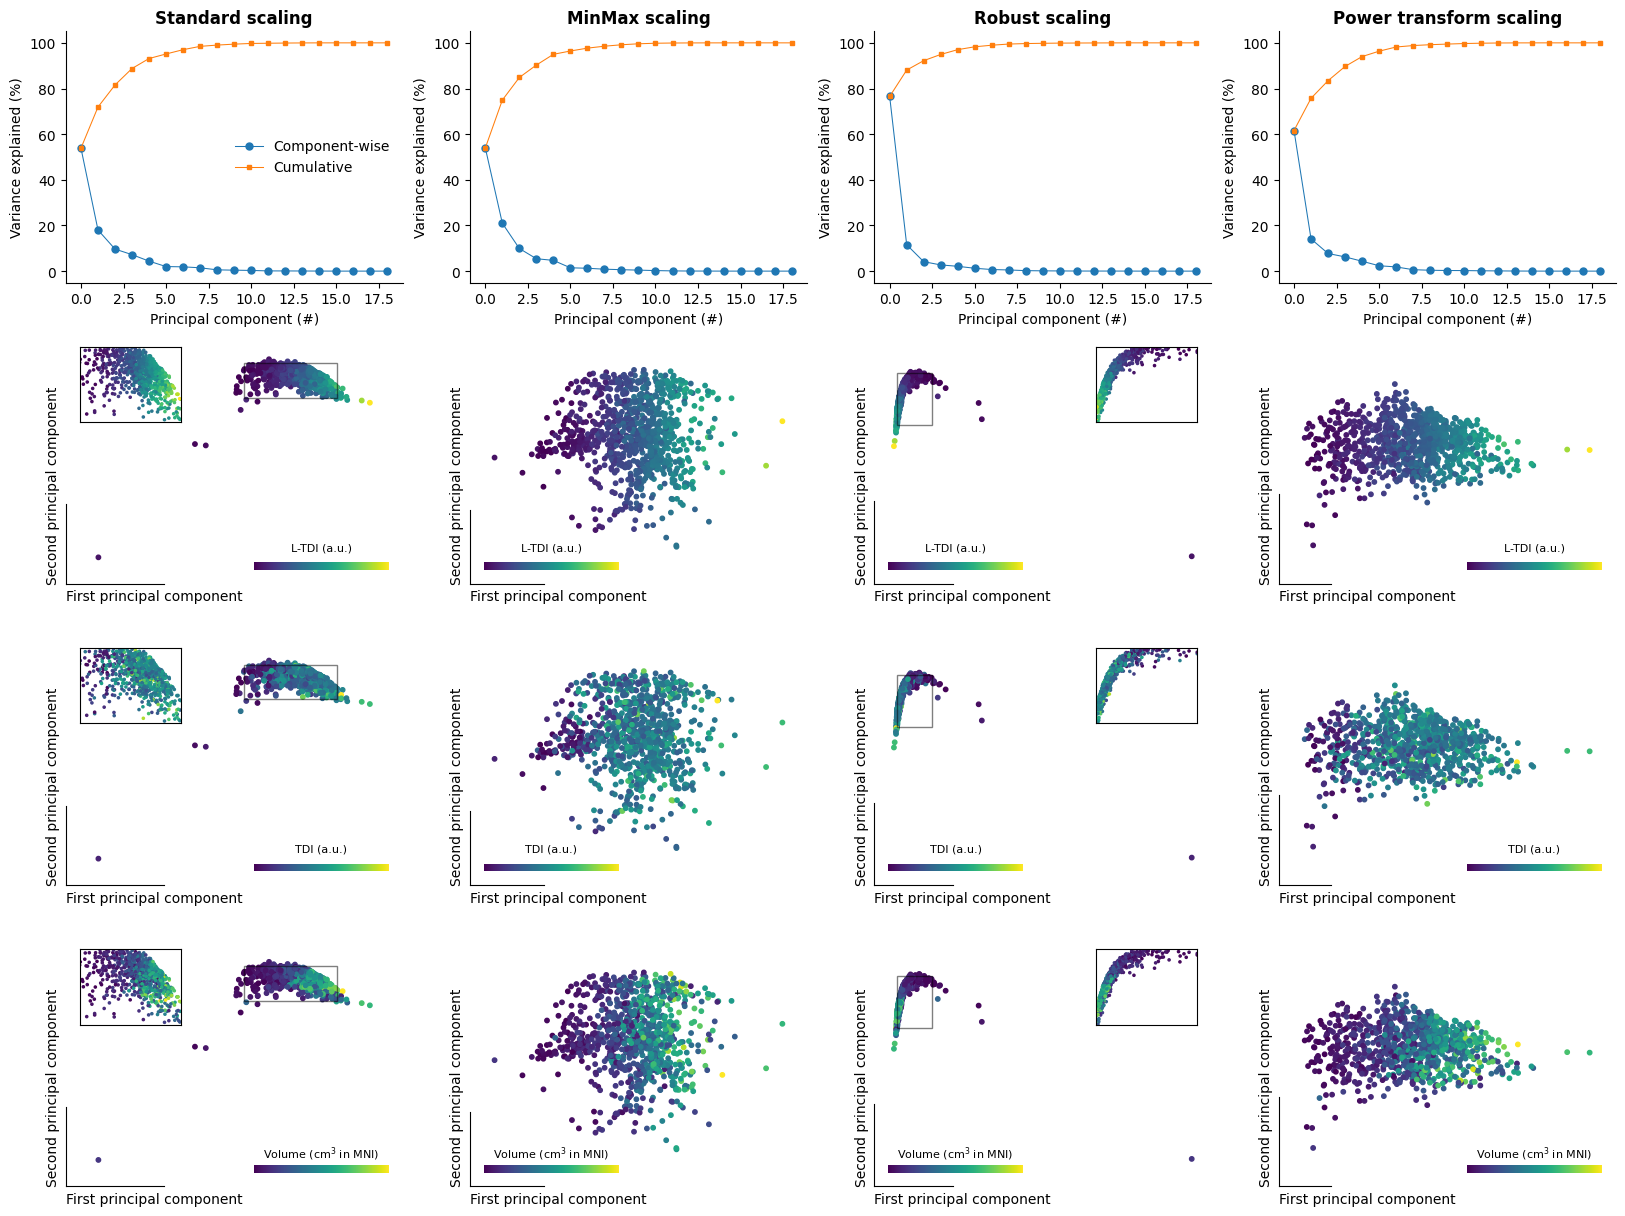

In [12]:
from sklearn.decomposition import PCA

os.makedirs(f"{RESULTS}/PCA-stats", exist_ok=True)

pca_standard = PCA()
components_standard = pca_standard.fit_transform(hcpex_standard) 

pca_minmax = PCA()
components_minmax = pca_minmax.fit_transform(hcpex_minmax) 

pca_robust = PCA()
components_robust  = pca_robust.fit_transform(hcpex_robust) 

pca_powerT = PCA()
components_powerT = pca_powerT.fit_transform(hcpex_powerT) 

# Inspections
pcas = [
    ("Standard scaling", pca_standard, components_standard),
    ("MinMax scaling", pca_minmax, components_minmax),
    ("Robust scaling", pca_robust, components_robust),
    ("Power transform scaling", pca_powerT, components_powerT),
]
fig, ax = plt.subplots(4, len(pcas), figsize=(5*len(pcas),15))
for i, (name, pca, comp) in enumerate(pcas):
    evr = pca.explained_variance_ratio_
    cum_evr = np.cumsum(evr)

    ax[0, i].plot(evr*100, marker="o", label="Component-wise", linewidth=.75, markersize=5)
    ax[0, i].plot(cum_evr*100, marker="s", label="Cumulative", linewidth=.75, markersize=3)

    ax[0, i].set_title(name, fontweight="bold")
    ax[0, i].set_xlabel("Principal component (#)")
    ax[0, i].set_ylabel("Variance explained (%)")
    ax[0, i].set_ylim(-5, 105)
    ax[0, i].spines[["top", "right"]].set_visible(False)

    if i == 0:
        ax[0, i].legend(frameon=False)

    sc = ax[1, i].scatter(comp[:,0], comp[:,1], c=hcpex_metrics["Whole lesion TDMap"], cmap="viridis", s=10)
    ax[1, i].set_xlabel("First principal component", loc="left")
    ax[1, i].set_ylabel("Second principal component", loc="bottom")
    ax[1, i].set_xticks([])
    ax[1, i].set_yticks([])
    if i==0:
        xmin, xmin_ = 5, 5
        xmax, xmax_ = 5, 10
        ymin, ymin_ = 5, 5
        ymax, ymax_ = 5, 10
    elif i==1:
        xmin, xmin_ = .25, .25
        xmax, xmax_ = .25, .5
        ymin, ymin_ = .25, .25
        ymax, ymax_ = .25, .25
    elif i==2:
        xmin, xmin_ = 10, 10
        xmax, xmax_ = 10, 30
        ymin, ymin_ = 5, 5
        ymax, ymax_ = 7, 10
    else:
        xmin, xmin_ = 2, 2
        xmax, xmax_ = 2, 2
        ymin, ymin_ = 3, 3
        ymax, ymax_ = 4, 4
    ax[1, i].set_xlim([comp[:,0].min()-xmin, comp[:,0].max()+xmax])
    ax[1, i].spines["bottom"].set_bounds(comp[:,0].min()-xmin_, comp[:,0].min()+xmax_)
    ax[1, i].set_ylim([comp[:,1].min()-ymin, comp[:,1].max()+ymax])
    ax[1, i].spines["left"].set_bounds(comp[:,1].min()-ymin_, comp[:,1].min()+ymax_)
    ax[1, i].spines[["top", "right"]].set_visible(False)
    cax = inset_axes(
        ax[1, i],
        width="40%",     # width relative to axes
        height="3%",   # height relative to axes
        loc="lower left" if (i==1 or i==2) else "lower right",
        borderpad=1
    )
    cbar = plt.colorbar(sc, cax=cax, orientation="horizontal")
    cbar.set_label("L-TDI (a.u.)", labelpad=-20, fontsize=8)
    cbar.outline.set_visible(False)
    cbar.set_ticks([])

    sc = ax[2, i].scatter(comp[:,0], comp[:,1], c=hcpex_metrics["Whole TDMap"], cmap="viridis", s=10)
    ax[2, i].set_xlabel("First principal component", loc="left")
    ax[2, i].set_ylabel("Second principal component", loc="bottom")
    ax[2, i].set_xticks([])
    ax[2, i].set_yticks([])
    ax[2, i].set_xlim([comp[:,0].min()-xmin, comp[:,0].max()+xmax])
    ax[2, i].spines["bottom"].set_bounds(comp[:,0].min()-xmin_, comp[:,0].min()+xmax_)
    ax[2, i].set_ylim([comp[:,1].min()-ymin, comp[:,1].max()+ymax])
    ax[2, i].spines["left"].set_bounds(comp[:,1].min()-ymin_, comp[:,1].min()+ymax_)
    ax[2, i].spines[["top", "right"]].set_visible(False)
    cax = inset_axes(
        ax[2, i],
        width="40%",     # width relative to axes
        height="3%",   # height relative to axes
        loc="lower left" if (i==1 or i==2) else "lower right",
        borderpad=1
    )
    cbar = plt.colorbar(sc, cax=cax, orientation="horizontal")
    cbar.set_label("TDI (a.u.)", labelpad=-20, fontsize=8)
    cbar.outline.set_visible(False)
    cbar.set_ticks([])

    sc = ax[3, i].scatter(comp[:,0], comp[:,1], c=hcpex_metrics["Whole tumor size (voxels)"]*voxel_size, cmap="viridis", s=10)
    ax[3, i].set_xlabel("First principal component", loc="left")
    ax[3, i].set_ylabel("Second principal component", loc="bottom")
    ax[3, i].set_xticks([])
    ax[3, i].set_yticks([])
    ax[3, i].set_xlim([comp[:,0].min()-xmin, comp[:,0].max()+xmax])
    ax[3, i].spines["bottom"].set_bounds(comp[:,0].min()-xmin_, comp[:,0].min()+xmax_)
    ax[3, i].set_ylim([comp[:,1].min()-ymin, comp[:,1].max()+ymax])
    ax[3, i].spines["left"].set_bounds(comp[:,1].min()-ymin_, comp[:,1].min()+ymax_)
    ax[3, i].spines[["top", "right"]].set_visible(False)
    cax = inset_axes(
        ax[3, i],
        width="40%",     # width relative to axes
        height="3%",   # height relative to axes
        loc="lower left" if (i==1 or i==2) else "lower right",
        borderpad=1
    )
    cbar = plt.colorbar(sc, cax=cax, orientation="horizontal")
    cbar.set_label("Volume (cm"+ r'$^3$'+" in MNI)", labelpad=-20, fontsize=8)
    cbar.outline.set_visible(False)
    cbar.set_ticks([])

    if (i==0 or i==2):
        x = comp[:, 0]
        y = comp[:, 1]
        x_lo, x_hi = np.percentile(x, [1, 99])
        y_lo, y_hi = np.percentile(y, [1, 99])
        mask = (x >= x_lo) & (x <= x_hi) & (y >= y_lo) & (y <= y_hi)


        c = hcpex_metrics["Whole lesion TDMap"].values
        axins = inset_axes(
            ax[1, i],
            width="30%",
            height="30%",
            loc="upper left" if i==0 else "upper right",
            borderpad=1
        )
        axins.scatter(x[mask], y[mask], c=c[mask], cmap="viridis", s=2.5)
        axins.set_xticks([])
        axins.set_yticks([])
        axins.set_xlim(x_lo, x_hi)
        axins.set_ylim(y_lo, y_hi)
        ax[1, i].indicate_inset_zoom(axins, edgecolor="black", linewidth=1)

        c = hcpex_metrics["Whole TDMap"].values
        axins = inset_axes(
            ax[2, i],
            width="30%",
            height="30%",
            loc="upper left" if i==0 else "upper right",
            borderpad=1
        )
        axins.scatter(x[mask], y[mask], c=c[mask], cmap="viridis", s=2.5)
        axins.set_xticks([])
        axins.set_yticks([])
        axins.set_xlim(x_lo, x_hi)
        axins.set_ylim(y_lo, y_hi)
        ax[2, i].indicate_inset_zoom(axins, edgecolor="black", linewidth=1)


        c = hcpex_metrics["Whole tumor size (voxels)"].values
        axins = inset_axes(
            ax[3, i],
            width="30%",
            height="30%",
            loc="upper left" if i==0 else "upper right",
            borderpad=1
        )
        axins.scatter(x[mask], y[mask], c=c[mask], cmap="viridis", s=2.5)
        axins.set_xticks([])
        axins.set_yticks([])
        axins.set_xlim(x_lo, x_hi)
        axins.set_ylim(y_lo, y_hi)
        ax[3, i].indicate_inset_zoom(axins, edgecolor="black", linewidth=1)

fig.savefig(f"{RESULTS}/PCA-stats/standardization-types_association-tract-volume.svg", dpi=200, format="svg")
fig.savefig(f"{RESULTS}/PCA-stats/standardization-types_association-tract-volume.pdf", dpi=300, format="pdf")

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

# --- Variables to correlate ---
variables = ["Whole lesion TDMap", "Whole TDMap", "Whole tumor size (voxels)", "OS (days) - corrected"]  # replace with exact column names in your dataframe
pcs_to_use = 4  

dfs = {}

# --- Containers ---
for i, (name, pca, comp) in enumerate(pcas):
    results = []

    for i in range(pcs_to_use):
        pc_name = f"PC{i+1}"
        pc_vals = comp[:, i]
        
        for iv, var in enumerate(variables):
            if iv==3: # Only patients that experienced an event
                mask = hcpex_metrics["status"] == 1
                y = hcpex_metrics[var].values[mask]
                x = pc_vals[mask]
            else:
                y = hcpex_metrics[var].values
                x = pc_vals
            
            # Pearson
            r_p, p_p = pearsonr(x, y)
            results.append({"PC": pc_name, "Variable": var, "Method": "Pearson", "correlation": r_p.round(4), "p-value": p_p.round(6)})
            
            # Spearman
            r_s, p_s = spearmanr(x, y)
            results.append({"PC": pc_name, "Variable": var, "Method": "Spearman", "correlation": r_s.round(4), "p-value": p_s.round(6)})

    # --- Convert to DataFrame ---
    df_corr = pd.DataFrame(results)

    # --- FDR correction ---
    # Apply FDR across all tests
    rejected, pvals_corrected, _, _ = multipletests(df_corr["p-value"].values, alpha=0.05, method='fdr_bh')
    df_corr["p-value (FDR)"] = pvals_corrected.round(4)
    df_corr["significant after FDR"] = rejected

    # --- Optional: pivot for easier visualization ---
    df_pivot = df_corr.pivot_table(index=["PC", "Variable"], columns="Method", values=["correlation","p-value","p-value (FDR)","significant after FDR"])
    df_pivot.to_csv(f"{RESULTS}/PCA-stats/Associations-PCs_Standardizer-{name.split(" ")[0]}.csv", sep=",")

    dfs[name] = df_corr

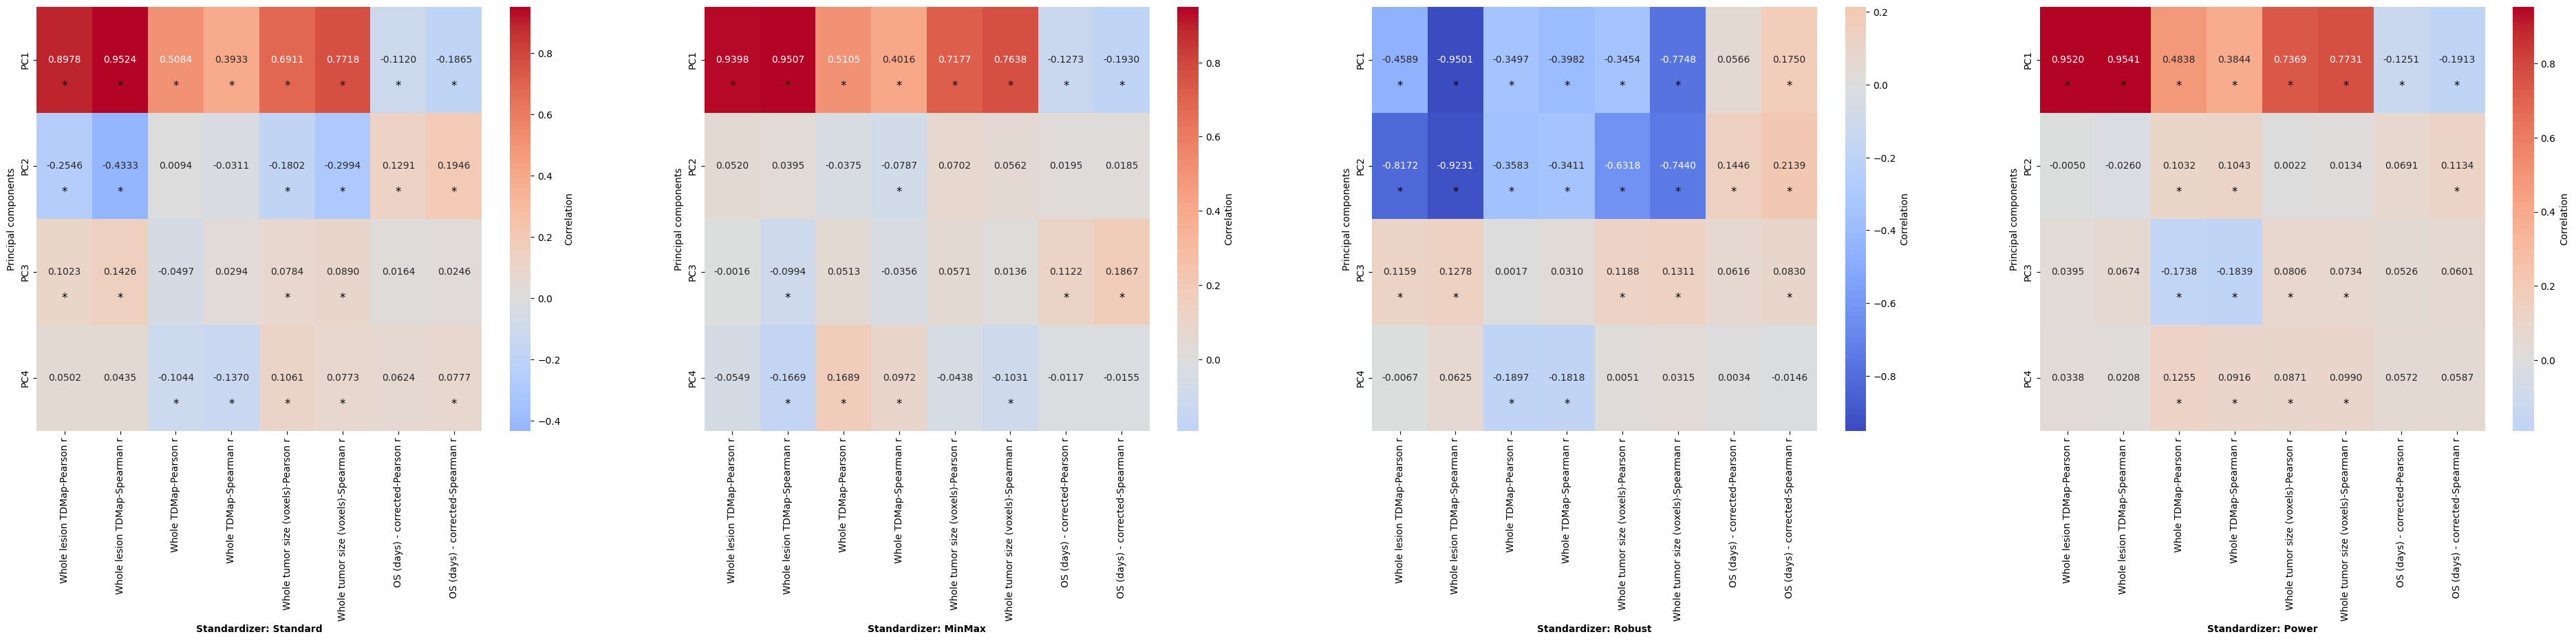

In [10]:
fig, ax = plt.subplots(1, len(pcas), figsize=(12*len(pcas), 8))

for i_ax, (name, pca, comp) in enumerate(pcas):
    df_corr = dfs[name]

    heatmap_data = pd.DataFrame(index=[f"PC{i+1}" for i in range(pcs_to_use)],
                                columns=pd.MultiIndex.from_product([variables, ["Pearson r", "Spearman r"]]))

    significance_data = pd.DataFrame(index=[f"PC{i+1}" for i in range(pcs_to_use)],
                                    columns=pd.MultiIndex.from_product([variables, ["Pearson sig", "Spearman sig"]]))

    # Fill the tables
    for i in range(pcs_to_use):
        pc_name = f"PC{i+1}"
        for var in variables:
            # Pearson
            r_p = df_corr.loc[(df_corr["PC"]==pc_name) & (df_corr["Variable"]==var) & (df_corr["Method"]=="Pearson"), "correlation"].values[0]
            sig_p = df_corr.loc[(df_corr["PC"]==pc_name) & (df_corr["Variable"]==var) & (df_corr["Method"]=="Pearson"), "significant after FDR"].values[0]
            heatmap_data.loc[pc_name, (var, "Pearson r")] = r_p
            significance_data.loc[pc_name, (var, "Pearson sig")] = sig_p
            
            # Spearman
            r_s = df_corr.loc[(df_corr["PC"]==pc_name) & (df_corr["Variable"]==var) & (df_corr["Method"]=="Spearman"), "correlation"].values[0]
            sig_s = df_corr.loc[(df_corr["PC"]==pc_name) & (df_corr["Variable"]==var) & (df_corr["Method"]=="Spearman"), "significant after FDR"].values[0]
            heatmap_data.loc[pc_name, (var, "Spearman r")] = r_s
            significance_data.loc[pc_name, (var, "Spearman sig")] = sig_s

    # --- Convert to float ---
    heatmap_data = heatmap_data.astype(float)

    # --- Plot heatmap ---
    sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="coolwarm", center=0, cbar_kws={"label": "Correlation"}, ax=ax[i_ax])

    # Overlay significance marks
    for i, pc in enumerate(heatmap_data.index):
        for j, (var, method) in enumerate(heatmap_data.columns):
            if significance_data.loc[pc, (var, f"{method.split()[0]} sig")]:
                ax[i_ax].text(j+0.5, i+0.75, "*", color="black", ha='center', va='center', fontsize=12)

    ax[i_ax].set_xlabel(f"Standardizer: {name.split(" ")[0]}", fontweight="bold")
    ax[i_ax].set_ylabel("Principal components")

fig.savefig(f"{RESULTS}/PCA-stats/PCs-associations.svg", dpi=200, format="svg")
fig.savefig(f"{RESULTS}/PCA-stats/PCs-associations.pdf", dpi=300, format="pdf")